# E-Commerce Data
This dataset consists of orders made in different countries from December 2010 to December 2011. The company is a UK-based online retailer that mainly sells unique all-occasion gifts. Many of its customers are wholesalers. 

Not sure where to begin? Scroll to the bottom to find challenges!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
retail = pd.read_csv("online_retail.csv")
retail.head(100)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
95,536378,22352,LUNCH BOX WITH CUTLERY RETROSPOT,6,12/1/10 9:37,2.55,14688.0,United Kingdom
96,536378,21212,PACK OF 72 RETROSPOT CAKE CASES,120,12/1/10 9:37,0.42,14688.0,United Kingdom
97,536378,21975,PACK OF 60 DINOSAUR CAKE CASES,24,12/1/10 9:37,0.55,14688.0,United Kingdom
98,536378,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,12/1/10 9:37,0.55,14688.0,United Kingdom


In [2]:
#Convert InvoiceDate to DateTime objects
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

In [3]:
#checking before making any changes
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
cancellations = retail[retail['InvoiceNo'].str.startswith('C', na=False)]
cancellations.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [7]:
print(f"Number of Cancellations: {len(cancellations)}")

Number of Cancellations: 9288


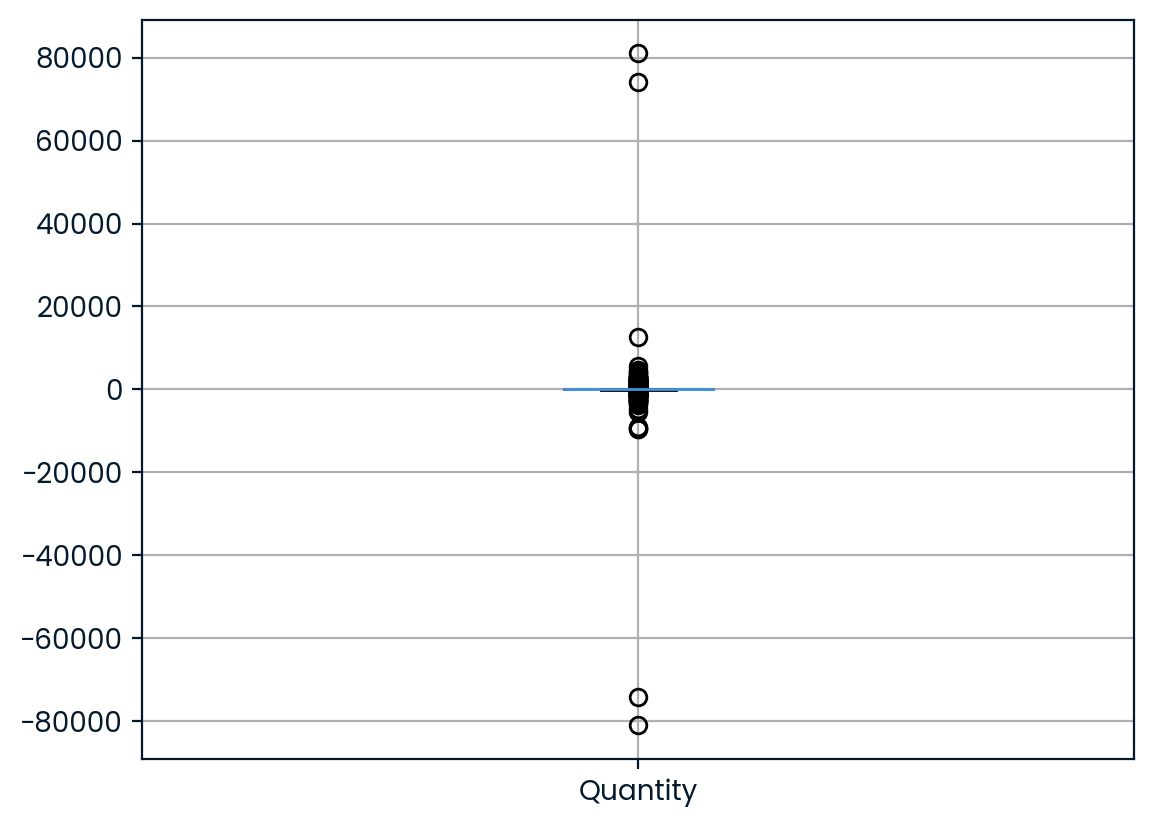

In [8]:
retail.boxplot(column=['Quantity'])
plt.show()

# Types of Analysis
### 1. Sales & Revenue
### 2. Customer Segmentation (RFM)
### 3. Cohort Analysis (Retention)
### 4. Market Basket Analysis (Association Rules)
### 5. Geographic Analysis
### 6. Cancellation & Returns Analysis
### 7. Product Iventory Insights

# 1. Sales and Revenue Analysis

In [9]:
# 1. Create a clean copy for sales analysis
# We exclude Quantities <= 0 and UnitPrice <= 0 to returns and adjustments
retail_sales = retail[(retail['Quantity']>0) & (retail['UnitPrice']>0)].copy()

In [10]:
# 2. Remove non-product StockCodes (optional but recommended)
# Filtering out 'POST', 'D', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE', etc
non_product_codes = ['POST', 'D', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE']
retail_sales = retail_sales[~retail_sales['StockCode'].isin(non_product_codes)]


In [11]:
# 3. Handle missing values in Description
retail_sales.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,527935.000000,527935,527935.000000,396473.000000
mean,10.564331,2011-07-04 21:27:13.827384064,3.299860,15301.447577
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:23:00,1.250000,13975.000000
50%,3.000000,2011-07-20 13:26:00,2.080000,15159.000000
75%,11.000000,2011-10-19 13:38:00,4.130000,16801.000000
max,80995.000000,2011-12-09 12:50:00,11062.060000,18287.000000
std,155.808389,NaN,15.856954,1709.768557


In [12]:
retail_sales['Description'].isnull().sum()
#there are no missing values in description

0

In [13]:
# 4. handling missing values in CustomerId
retail_sales['CustomerID'] = retail_sales['CustomerID'].fillna(0)

In [14]:
# 5. Calculate revenue
retail_sales['Revenue'] = retail_sales['Quantity']*retail_sales['UnitPrice']

In [15]:
# retail_sales['Revenue'].count()
retail_sales['Revenue'].sum()


10290234.482999997

In [19]:
retail_sales['CustomerID'].duplicated().sum()


523600

## Data Dictionary
| Variable    | Explanation                                                                                                                       |
|-------------|-----------------------------------------------------------------------------------------------------------------------------------|
| InvoiceNo   | A 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c' it indicates a cancellation. |
| StockCode   | A 5-digit integral number uniquely assigned to each distinct product.                                                             |
| Description | Product (item) name                                                                                                               |
| Quantity    | The quantities of each product (item) per transaction                                                                             |
| InvoiceDate | The day and time when each transaction was generated                                                                              |
| UnitPrice   | Product price per unit in sterling (pound)                                                                                        |
| CustomerID  | A 5-digit integral number uniquely assigned to each customer                                                                      |
| Country     | The name of the country where each customer resides                                                                               |

## Don't know where to start?

**Challenges are brief tasks designed to help you practice specific skills:**

- 🗺️ **Explore**: Negative order quantities indicate returns. Which products have been returned the most?
- 📊 **Visualize**: Create a plot visualizing the profits earned from UK customers weekly, monthly, and quarterly.
- 🔎 **Analyze**: Are order sizes from countries outside the United Kingdom significantly larger than orders from inside the United Kingdom?

**Scenarios are broader questions to help you develop an end-to-end project for your portfolio:**

You are working for an online retailer. Currently, the retailer sells over 4000 unique products. To take inventory of the items, your manager has asked you whether you can group the products into a small number of categories. The categories should be similar in terms of price and quantity sold and any other characteristics you can extract from the data.

You will need to prepare a report that is accessible to a broad audience. It should outline your motivation, steps, findings, and conclusions.